In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd
from pathlib import Path

import networkx as nx

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticke
from matplotlib.colors import LinearSegmentedColormap

from matrix_processing_helpers import sparsify_global_percentile
from plot_helpers import plot_rollout_graph, plot_feature_ranking_comparison

### Load data

In [2]:
# results_local = np.load("Results_TR/attention_rollout_local/rollout.npz")

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

In [3]:
print(feature_names)

['1,5-Anhydrosorbitol (mM)', '2-Aminobutyric acid (mM)', '2-Hydroxybutyric acid (mM)', '2-Oxoglutaric acid (mM)', '3-Hydroxyisobutyric acid (mM)', 'Acetic acid (mM)', 'Acetoacetic acid (mM)', 'Acetone (mM)', 'Alanine (mM)', 'Albumin (g/dl)', 'Apolipoprotein B (mg/ml)', 'Arginine (mM)', 'Asparagine (mM)', 'Aspartate (mM)', 'BCAA to AAA (Phe+Tyr) ratio (unitless)', 'Betaine (mM)', 'Bilirubin (mg/dl)', 'C reactive protein (mg/dl)', 'Calcium (mg/dl)', 'Choline (mM)', 'Citric acid (mM)', 'Creatine (mM)', 'Creatinine (mM)', 'Cystine (mM)', 'D-Galactose (mM)', 'Dimethylamine (mM)', 'Dimethylsulfone (mM)', 'Erythrocyte sedimentation rate (mm/h)', 'Erythrocytes (T/l)', 'Estimated Glomerular Filtration Rate (ml/min/1.73m²)', 'Ethanol (mM)', 'Formic acid (mM)', 'Glucose (mM)', 'Glutamic acid (mM)', 'Glutamine (mM)', 'Glutamine to glutamate ratio (unitless)', 'Glyc A (mM)', 'GlycB to GlycA ratio (unitless)', 'Glycerol (mM)', 'Glycine (mM)', 'HDL cholesterol (mg/dl)', 'Histidine (mM)', 'Iron (µg/dl

In [3]:
feature_names_short = ['1,5-Anhydrosorbitol', '2-Aminobutyric \n acid', '2-Hydroxybutyric \n acid', 
                       '2-Oxoglutaric \n acid', '3-Hydroxyisobutyric \n acid', 'Acetic \n acid', 
                       'Acetoacetic \n acid', 'Acetone', 'Alanine', 'Albumin', 
                       'Apolipoprotein B', 'Arginine', 'Asparagine', 'Aspartate', 
                       'BCAA to AAA \n ratio', 'Betaine', 'Bilirubin', 'C reactive \n protein', 
                       'Calcium', 'Choline', 'Citric \n acid', 'Creatine', 'Creatinine', 
                       'Cystine', 'D-Galactose', 'Dimethylamine', 'Dimethylsulfone', 
                       'Erythrocyte \n sedimentation \n rate', 'Erythrocytes', 
                       'Estimated \n Glomerular \n Filtration \n Rate', 'Ethanol', 'Formic acid', 
                       'Glucose', 'Glutamic \n acid', 'Glutamine', 
                       'Glutamine to \n glutamate ratio', 'Glyc A', 'GlycB to \n GlycA ratio', 
                       'Glycerol', 'Glycine', 'HDL cholesterol', 'Histidine', 'Iron', 
                       'LDL cholesterol', 'Lactate to \n pyruvate ratio', 'Lactic acid', 
                       'Leucine', 'Leukocytes', 'Lipoprotein(a)', 'Lysine', 
                       'Methanol', 'Methionine', 'Myo-inositol', 'N,N-Dimethylglycine', 
                       'Non-albumin \n protein', 'Ornithine', 'Phenylalanine', 'Platelets', 
                       'Proline', 'Pyruvic \n acid', 'SPC', 'Sarcosine', 'Serine', 
                       'Succinic \n acid', 'Threonine', 'Transferrin', 'Triglycerides', 
                       'Trimethylamine-N-oxide', 'Tyrosine', 'Urate', 'Urea', 
                       'Urea to creatinine \n ratio']

In [4]:
feature_abbrev = ["1,5-AG", "2-AB", "2-HB", "2-OG", "3-HIB", "Acetate", "AcAc", "Acetone", 
                  "Ala", "Alb", "ApoB", "Arg", "Asn", "Asp", "BCAA/AAA", "Bet", "Bili", 
                  "CRP", "Ca", "Cho", "Citrate", "Crn", "Creat", "Cys-Cys", "Gal", 
                  "DMA", "DMSO2", "ESR", "RBC", "eGFR", "EtOH", "Formate", "Gluc", "Glu-ac", 
                  "Gln", "Gln/Glu", "GlycA", "GlycB/A", "Glyc", "Gly", "HDL-C", "His", "Fe", 
                  "LDL-C", "Lac/Pyr", "Lac", "Leu", "WBC", "Lp(a)", "Lys", "MeOH", "Met", 
                  "MI", "DMG", "NAP", "Orn", "Phe", "Plt", "Pro", "Pyr", "SPC", "Sar", 
                  "Ser", "Succ", "Thr", "Tf", "TG", "TMAO", "Tyr", "Urate", "Urea", "Urea/Cr"]

### Attention matrices

In [5]:
ROLL_LOC = Path("Results/rollout_local")
ROLL_GLOB = Path("Results/rollout_global")
FIG_DIR = Path("Results/attention_plots")

cmap_attn = LinearSegmentedColormap.from_list("black_green", ["black", "#00FF00"])    

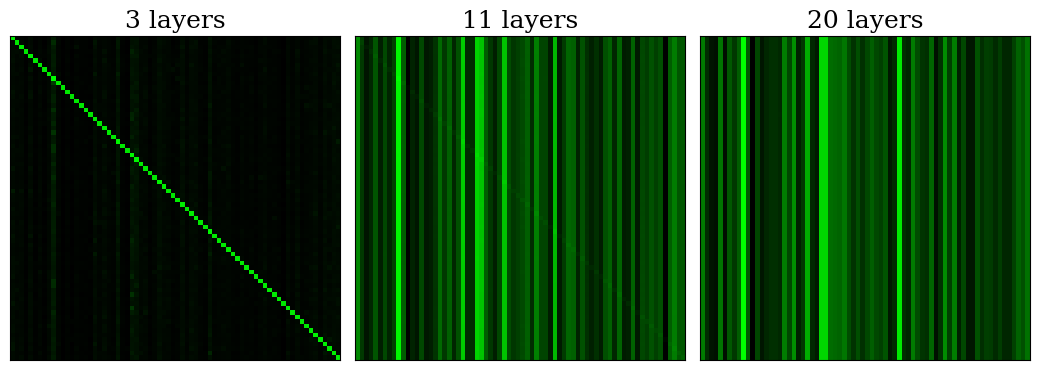

In [6]:
# ROLL_DIR = Path("Results/rollout_global")
N_LAYERS = [3, 11, 20]
plt.rcParams["font.family"] = "serif"
cmap_attn = LinearSegmentedColormap.from_list("black_green", ["black", "#00FF00"])

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8))
axes = axes.flatten()

for i, layer in enumerate(N_LAYERS):
    results_rollout = np.load(ROLL_GLOB / f"{layer}layers/rollout{layer}layers.npz")

    R = results_rollout['rollout']
    # np.fill_diagonal(R, 0)
    # R = sparsify_global_percentile(R, q=90, keep_diagonal=True)
    
    # plt.figure(figsize=(10, 11))
    axes[i].imshow(R, aspect='auto', cmap=cmap_attn)
    axes[i].set_title(f"{layer} layers", fontsize=18)  
  
    # axes[i].set_xticks(ticks=np.arange(len(feature_abbrev)),
    #            labels=feature_abbrev,
    #            rotation=90,
    #            fontsize=11)
    
    # plt.xticks(ticks=indices_R,
    #            labels=lst_plot_R,
    #            rotation=90,
    #            fontsize=18)

    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.savefig(FIG_DIR / "attention_rollout.pdf", bbox_inches="tight")
plt.show()

In [19]:
from matplotlib.patches import Rectangle, ConnectionPatch
from mpl_toolkits.axes_grid1 import make_axes_locatable


def draw_matrix_with_external_zoom(fig, ax, M, title, 
                                   center=(50, 50), size=30, cmap="magma", 
                                   patch_color="red", vmin=None, vmax=None):
    """
    Draw one matrix with an external zoom inset to its right.
    This function is meant to be called inside a multi-panel figure.
    """

    # Main matrix
    im = ax.imshow(M, cmap=cmap, aspect="equal", vmin=vmin, vmax=vmax, interpolation="nearest")

    ax.set_title(title, fontsize=16, pad=6)
    ax.set_xticks([])
    ax.set_yticks([])

    cy, cx = center
    half = size // 2

    y1 = max(cy - half, 0)
    y2 = min(cy + half, M.shape[0])
    x1 = max(cx - half, 0)
    x2 = min(cx + half, M.shape[1])

    zoom_region = M[y1:y2, x1:x2]

    # Selection square
    rect = Rectangle((x1, y1), x2 - x1, y2 - y1, 
                     edgecolor=patch_color, facecolor="none", linewidth=2.8)
    ax.add_patch(rect)

    # Create external zoom axis to the right of the matrix
    divider = make_axes_locatable(ax)
    axins = divider.append_axes("right", size="42%", pad=0.18)

    axins.imshow(zoom_region, cmap=cmap, aspect="equal", vmin=vmin, vmax=vmax, 
                 interpolation="nearest")

    axins.set_xticks([])
    axins.set_yticks([])

    for spine in axins.spines.values():
        spine.set_edgecolor(patch_color)
        spine.set_linewidth(2.8)

    # Non-crossing connector lines
    con_top = ConnectionPatch(xyA=(x2, y1), coordsA=ax.transData, xyB=(0, 1), 
                              coordsB=axins.transAxes, color=patch_color, linewidth=1.5)

    con_bottom = ConnectionPatch(xyA=(x2, y2), coordsA=ax.transData, xyB=(0, 0), 
                                 coordsB=axins.transAxes, color=patch_color, linewidth=1.5)

    fig.add_artist(con_top)
    fig.add_artist(con_bottom)

    return im, axins

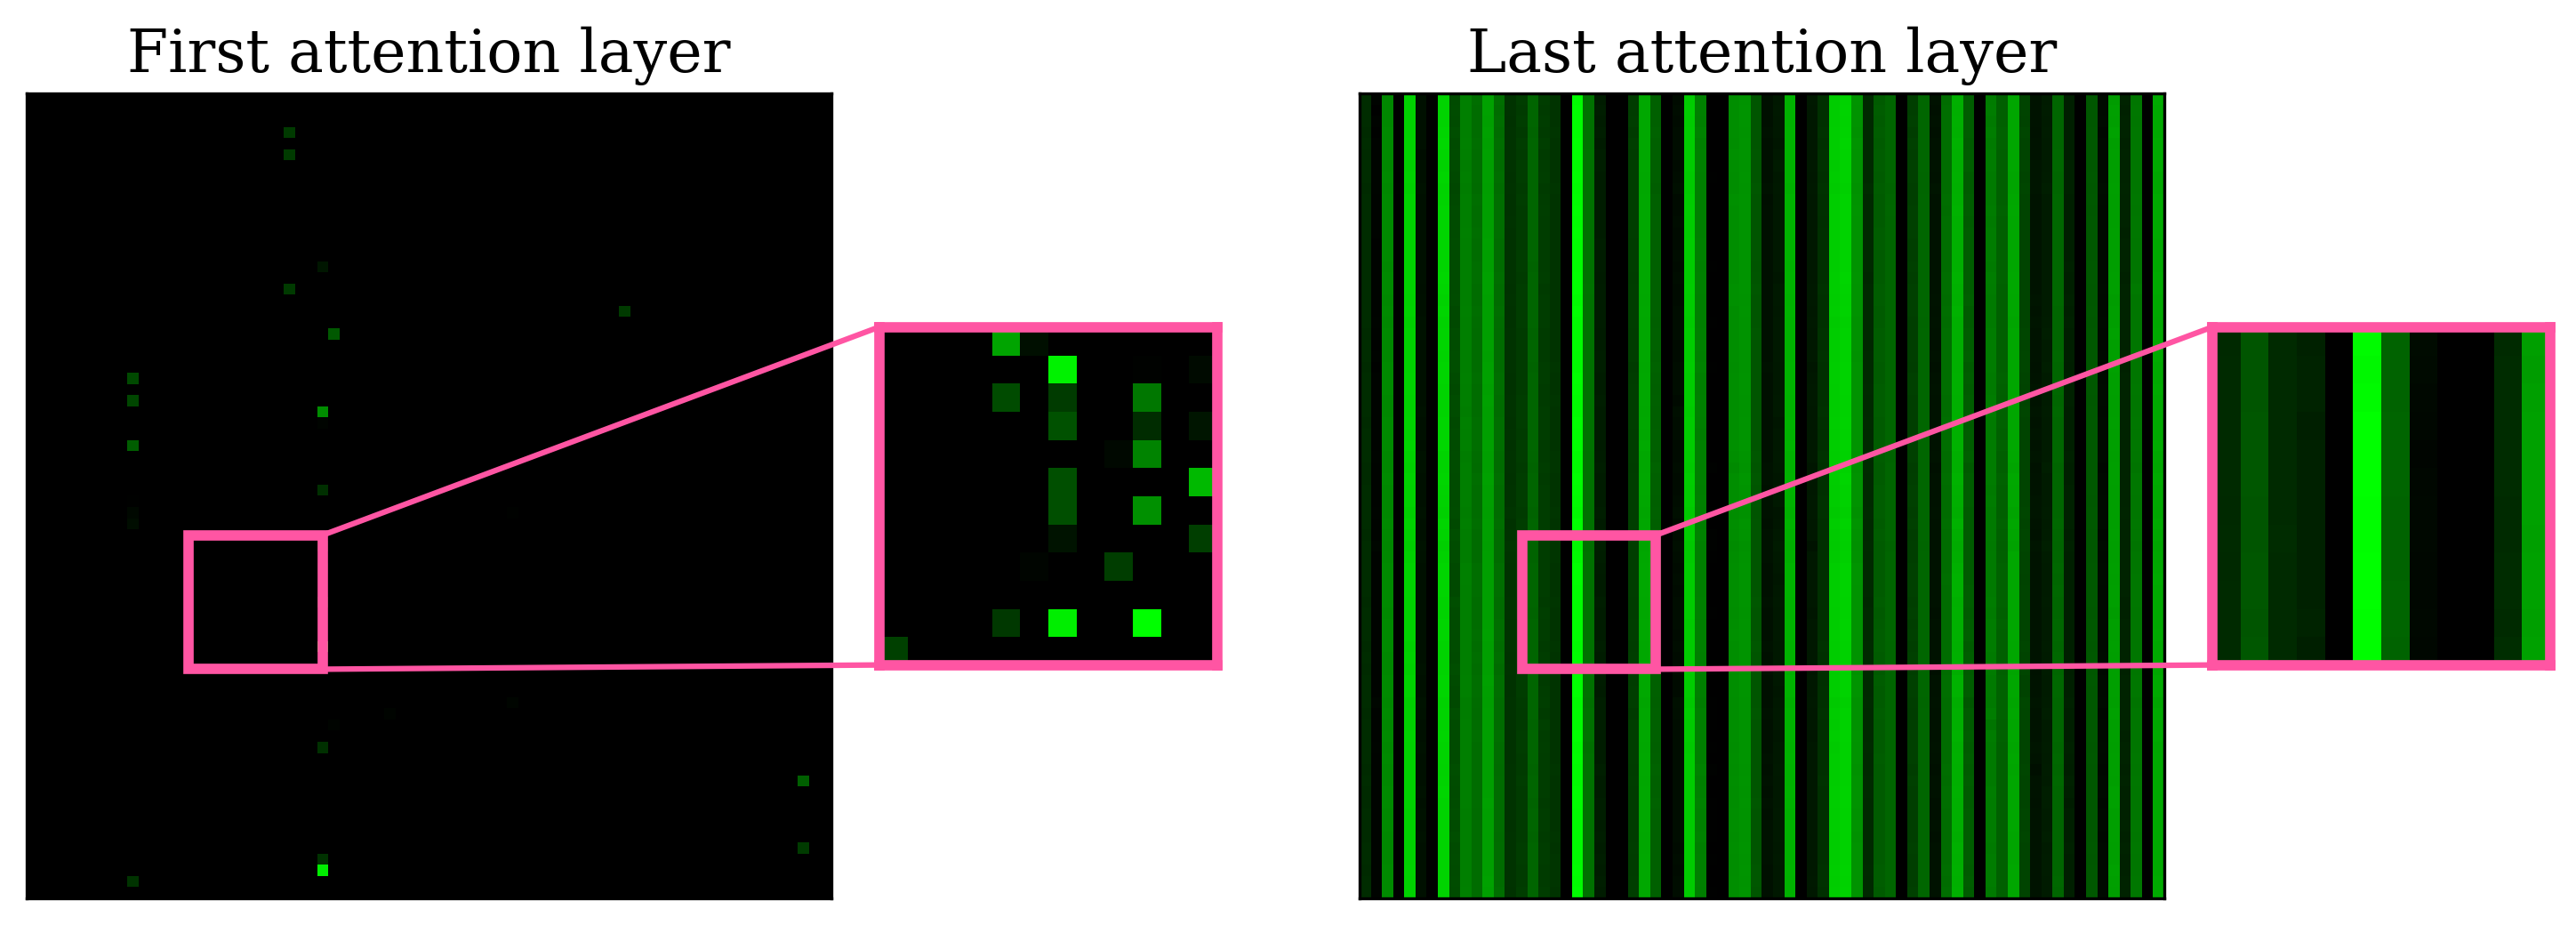

In [23]:
N_LAYERS = 11
with open(f"Results/rollout_local/{N_LAYERS}layers/attn_matrices{N_LAYERS}layers.pkl", "rb") as f:
    attn_matrices = pickle.load(f)

attn_list = [np.mean(attn_matrices[key]['attn_matrix'], axis=0) for key in attn_matrices.keys()]

matrices = [attn_list[0], attn_list[-1]]

titles = ["First attention layer", "Last attention layer"]
centers = 4*[(45, 20)]
sizes = 4*[12]

# Shared normalization across all matrices
all_values = np.concatenate([M.ravel() for M in matrices])
vmin = np.percentile(all_values, 2)
vmax = np.percentile(all_values, 99)

fig, axes = plt.subplots(1, 2, figsize=(11, 8), dpi=300)

axes = axes.ravel()

cmap_attn = LinearSegmentedColormap.from_list("black_green",
                                              [(0.0, "black"), (0.35, "black"), (1.0, "#00FF00")])

# cmap_attn = LinearSegmentedColormap.from_list("black_green", ["black", "#00FF00"])

for ax, M, title, center, size in zip(axes, matrices, titles, centers, sizes):
    im, axins = draw_matrix_with_external_zoom(fig=fig, ax=ax, M=M, title=title, 
                                               center=center, size=size, cmap=cmap_attn,
                                               patch_color="#FF55A3",
                                               # vmin=vmin, vmax=vmax
                                              )

plt.subplots_adjust(left=0.04, right=0.90, bottom=0.05, top=0.92, wspace=0.12, hspace=0.10)

plt.savefig(FIG_DIR / "attn_matrices_zoom.pdf", bbox_inches="tight")

plt.show()

### Video